**Compare the throughput curve extracted from ScopeSim to the analytic ETC throughput curve.**

Send in a uniform illumination source with a constant flux of 1 photlam defined over the slit aperture, and extract the resulting bandpass integrated along the slit spatial axis. All detector effects are turned off for the sake of this exercise.

In [ ]:
import scopesim as sim
from scopesim.source.source_templates import uniform_illumination
from scopesim.source.source import Source
sim.link_irdb("../..")

import numpy as np
from astropy.wcs import WCS
from astropy import units as u
import matplotlib.pyplot as plt
from synphot import SourceSpectrum
from synphot.units import PHOTLAM
from synphot.models import ConstFlux1D

In [ ]:
# Set up
etc_area = np.pi * (0.75*u.m*0.5)**2
pixel_scale = 0.8 * u.arcsec
bin_width = 5e-04 * u.um

cmdlss = sim.UserCommands(use_instrument="UVEX", set_modes=['lss'])

cmdlss["!SIM.spectral.spectral_bin_width"] = bin_width.value
cmdlss["!SIM.spectral.spectral_resolution"] = 3000

cmdlss["!TEL.area"] = etc_area  # m^2, must match the ETC

optlss = sim.OpticalTrain(cmdlss)
om = optlss.optics_manager

# Run at reasonably high spectral resolution and bin width, but reduce oversampling
# (whether we oversample or not does not seem to affect the throughput)
om['slit_psf'].meta['oversample_flag'] = True
om['slit_psf'].meta['oversampling'] = 2
#om['slit_psf'].meta['include'] = False

om['detector_psf'].meta['oversample_flag'] = True
om['detector_psf'].meta['oversampling'] = 2
#om['detector_psf'].meta['include'] = False

# And turn off detector effects for now
om['lss_dark_current'].meta['include'] = False
om['lss_shot_noise'].meta['include'] = False
om['lss_readout_noise'].meta['include'] = False
om['lss_ad_conversion'].meta['include'] = False # keep in electrons
#om['spacecraft_pointing'].meta['inclue'] = False

# The detector gain was also changed in the config to be 1.0
# ...can we set this from a notebook?


py.warnings - WARNING: /home/eshread/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:169: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

astar.scopesim.utils - ERROR: File cannot be found: tbd_det_linearity.dat
astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits


Use a uniform flux source covering the entire slit aperture.

Or use a uniform flux point source.

In [3]:
lam_array = np.arange(0.115, 0.355, 0.01)*u.um 
sp = SourceSpectrum(ConstFlux1D, amplitude=1*PHOTLAM)
constant_source = uniform_illumination(xs=[12599., 12601.], ys=[-1800., 1800.], pixel_scale=0.8, spectrum=sp)
#constant_source = Source(x=[12600.], y=[0.], spectra = sp, weight=[1.0], ref=[0])

In [4]:
# Run the simulation
optlss.observe(constant_source, update=True)
hdulist_lss_ = optlss.readout()[0]

py.warnings - WARNING: /home/eshread/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:211: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



 FOV effects:   0%|          | 0/3 [00:00<?, ?it/s]

astar.scopesim.effects.spectral_trace_list_utils - Loaded dispersion from file: /home/eshread/UVEX/uvex-mission/irdb/UVEX/data_files/UVIM_LSS_dispersion.dat
astar.scopesim.optics.image_plane - WARNING: No BUNIT found in added HDU.
astar.scopesim.detector.detector_manager - Extracting from 2 detectors...


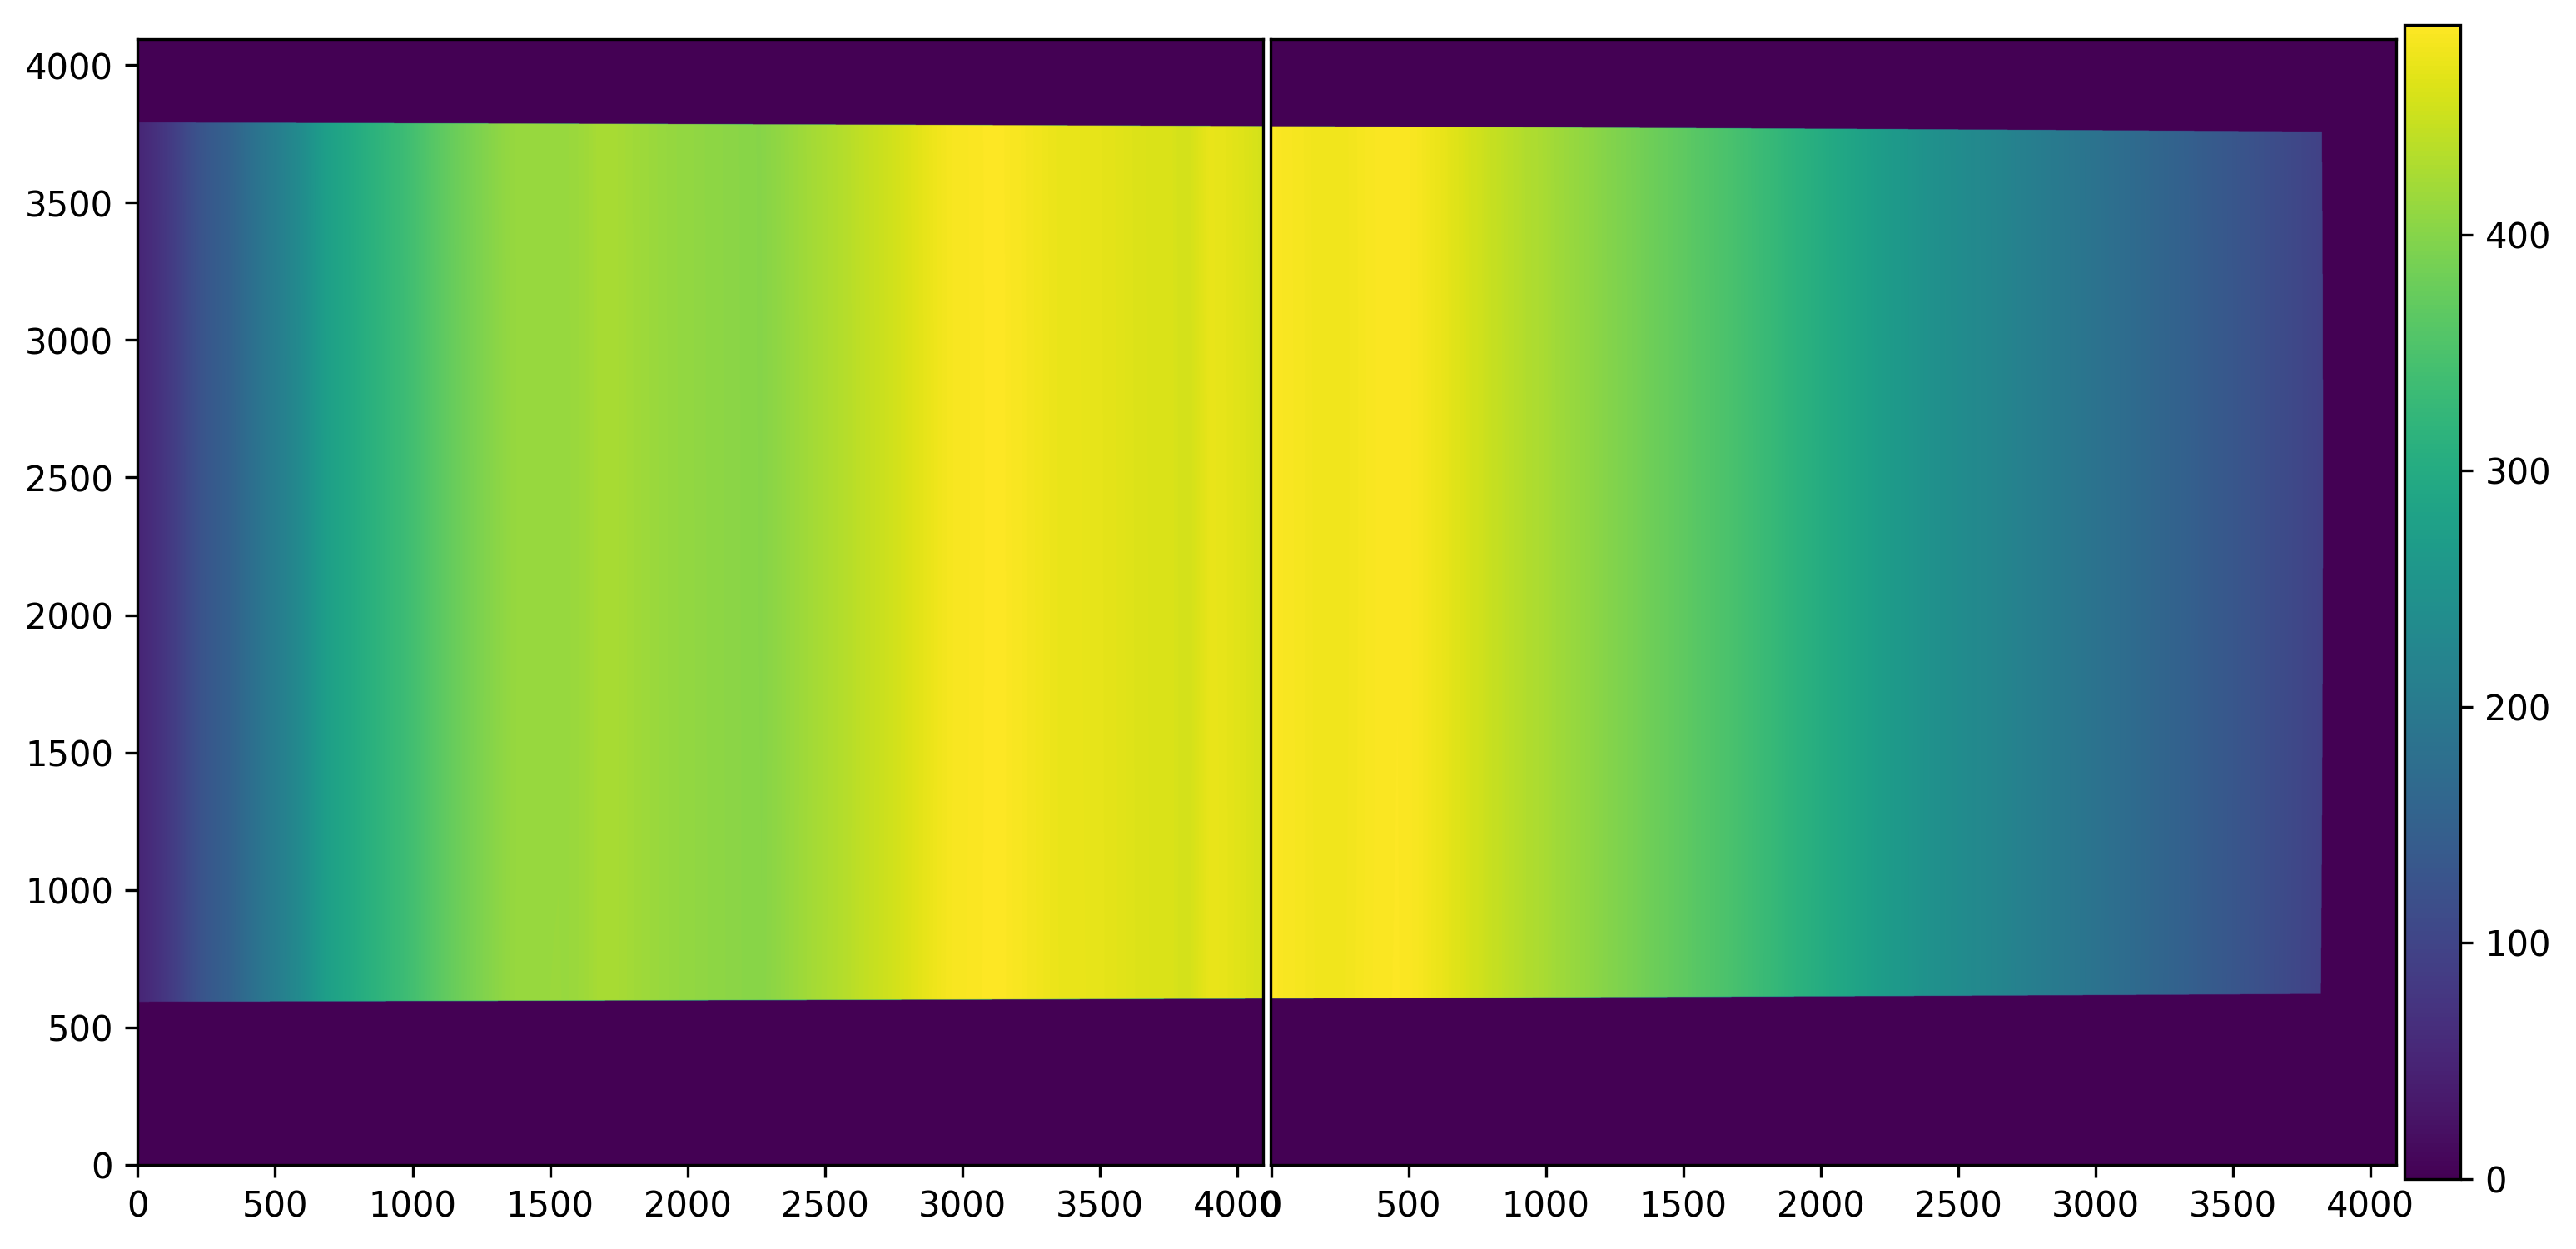

In [5]:
# Plot the output image
fig, axs = plt.subplots(ncols=3, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1, 0.05]}, dpi=300)
ax0, ax1, cax = axs
ax0.tick_params(axis="both", labelsize=10)
ax1.tick_params(axis="x", labelsize=10)
ax1.set_yticks([])
# is the slit image supposed to cover the full detector plane??
im0 = ax0.imshow(hdulist_lss_[1].data, origin='lower')
im1 = ax1.imshow(hdulist_lss_[2].data, origin='lower')

cbar = fig.colorbar(im1, cax=cax)
plt.subplots_adjust(wspace=0.01)
plt.show()

In [6]:
# Now rectify the spectra
tracelist = optlss["spectral_traces"]
rectified = tracelist.rectify_traces(hdulist_lss_, xi_min=-1800., xi_max=1800., bin_width=bin_width.value)

astar.scopesim.effects.spectral_trace_list - Full wavelength range: 0.12 .. 0.35 um


 Traces:   0%|          | 0/1 [00:00<?, ?it/s]

astar.scopesim.effects.spectral_trace_list_utils - Rectifying UVIM_LSS_trace (0.12 .. 0.35 um)


Ratio of raw and rectified image electron counts (should be 1): 1.00
Raw image electron count: 914450.1680684077
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  468                                                  NAXIS2  =                 4501                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =                  1.0 / Pixel coordinate of reference point            CRPIX2  =                  1.0 / Pixel coordinate of reference point            CDELT1  =                5E-10 / [m] Coordinate increment at reference point    CDELT2 

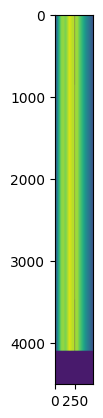

In [7]:
# Verify flux is conserved during rectification
raw_flux = (float(hdulist_lss_[1].data.sum()) + float(hdulist_lss_[2].data.sum())) * hdulist_lss_[1].header['CDELT1D'] * hdulist_lss_[1].header['CDELT2D'] # multiply by pixel area to get result in electrons
rectified_flux = rectified[1].data.sum() * bin_width.value * pixel_scale.value
print(f"Ratio of raw and rectified image electron counts (should be 1): {rectified_flux / raw_flux:.2f}")
print('Raw image electron count:', raw_flux)
print(rectified[1].header)
print(hdulist_lss_[1].header)
plt.imshow(rectified[1].data)
plt.show()

**Load the LSS bandpass from the ETC.**

The slit throughput for the spectrograph bandpass in the ETC is calculated assuming a point source. Since we are considering a uniform illumination source over the whole aperture, we should divide out by this factor.

In [8]:
import sys
sys.path.append("/home/eshread/UVEX/uvex-mission/uvex-mission")
import uvex
from uvex.sensitivity import config

UVEX = config.UVEX()
slit_thru = UVEX.SLIT_THROUGHPUT
#slit_thru = 1.

lss_bandpass_etc_file = "/home/eshread/UVEX/uvex-mission/uvex-mission/uvex/sensitivity/notebooks/bandpass_files/lss_bandpass.txt"

lss_bandpass_etc_data = np.loadtxt(lss_bandpass_etc_file)
lss_bandpass_etc_wave = (lss_bandpass_etc_data[:,0] * u.AA).value
lss_bandpass_etc_throughput = lss_bandpass_etc_data[:,1] / slit_thru

Pixel area: 1.0000000000000006e-10 m2   Slit area: 1.1250000000000002e-06 m2
Total input count rate: 26.999999999999996 ph / s


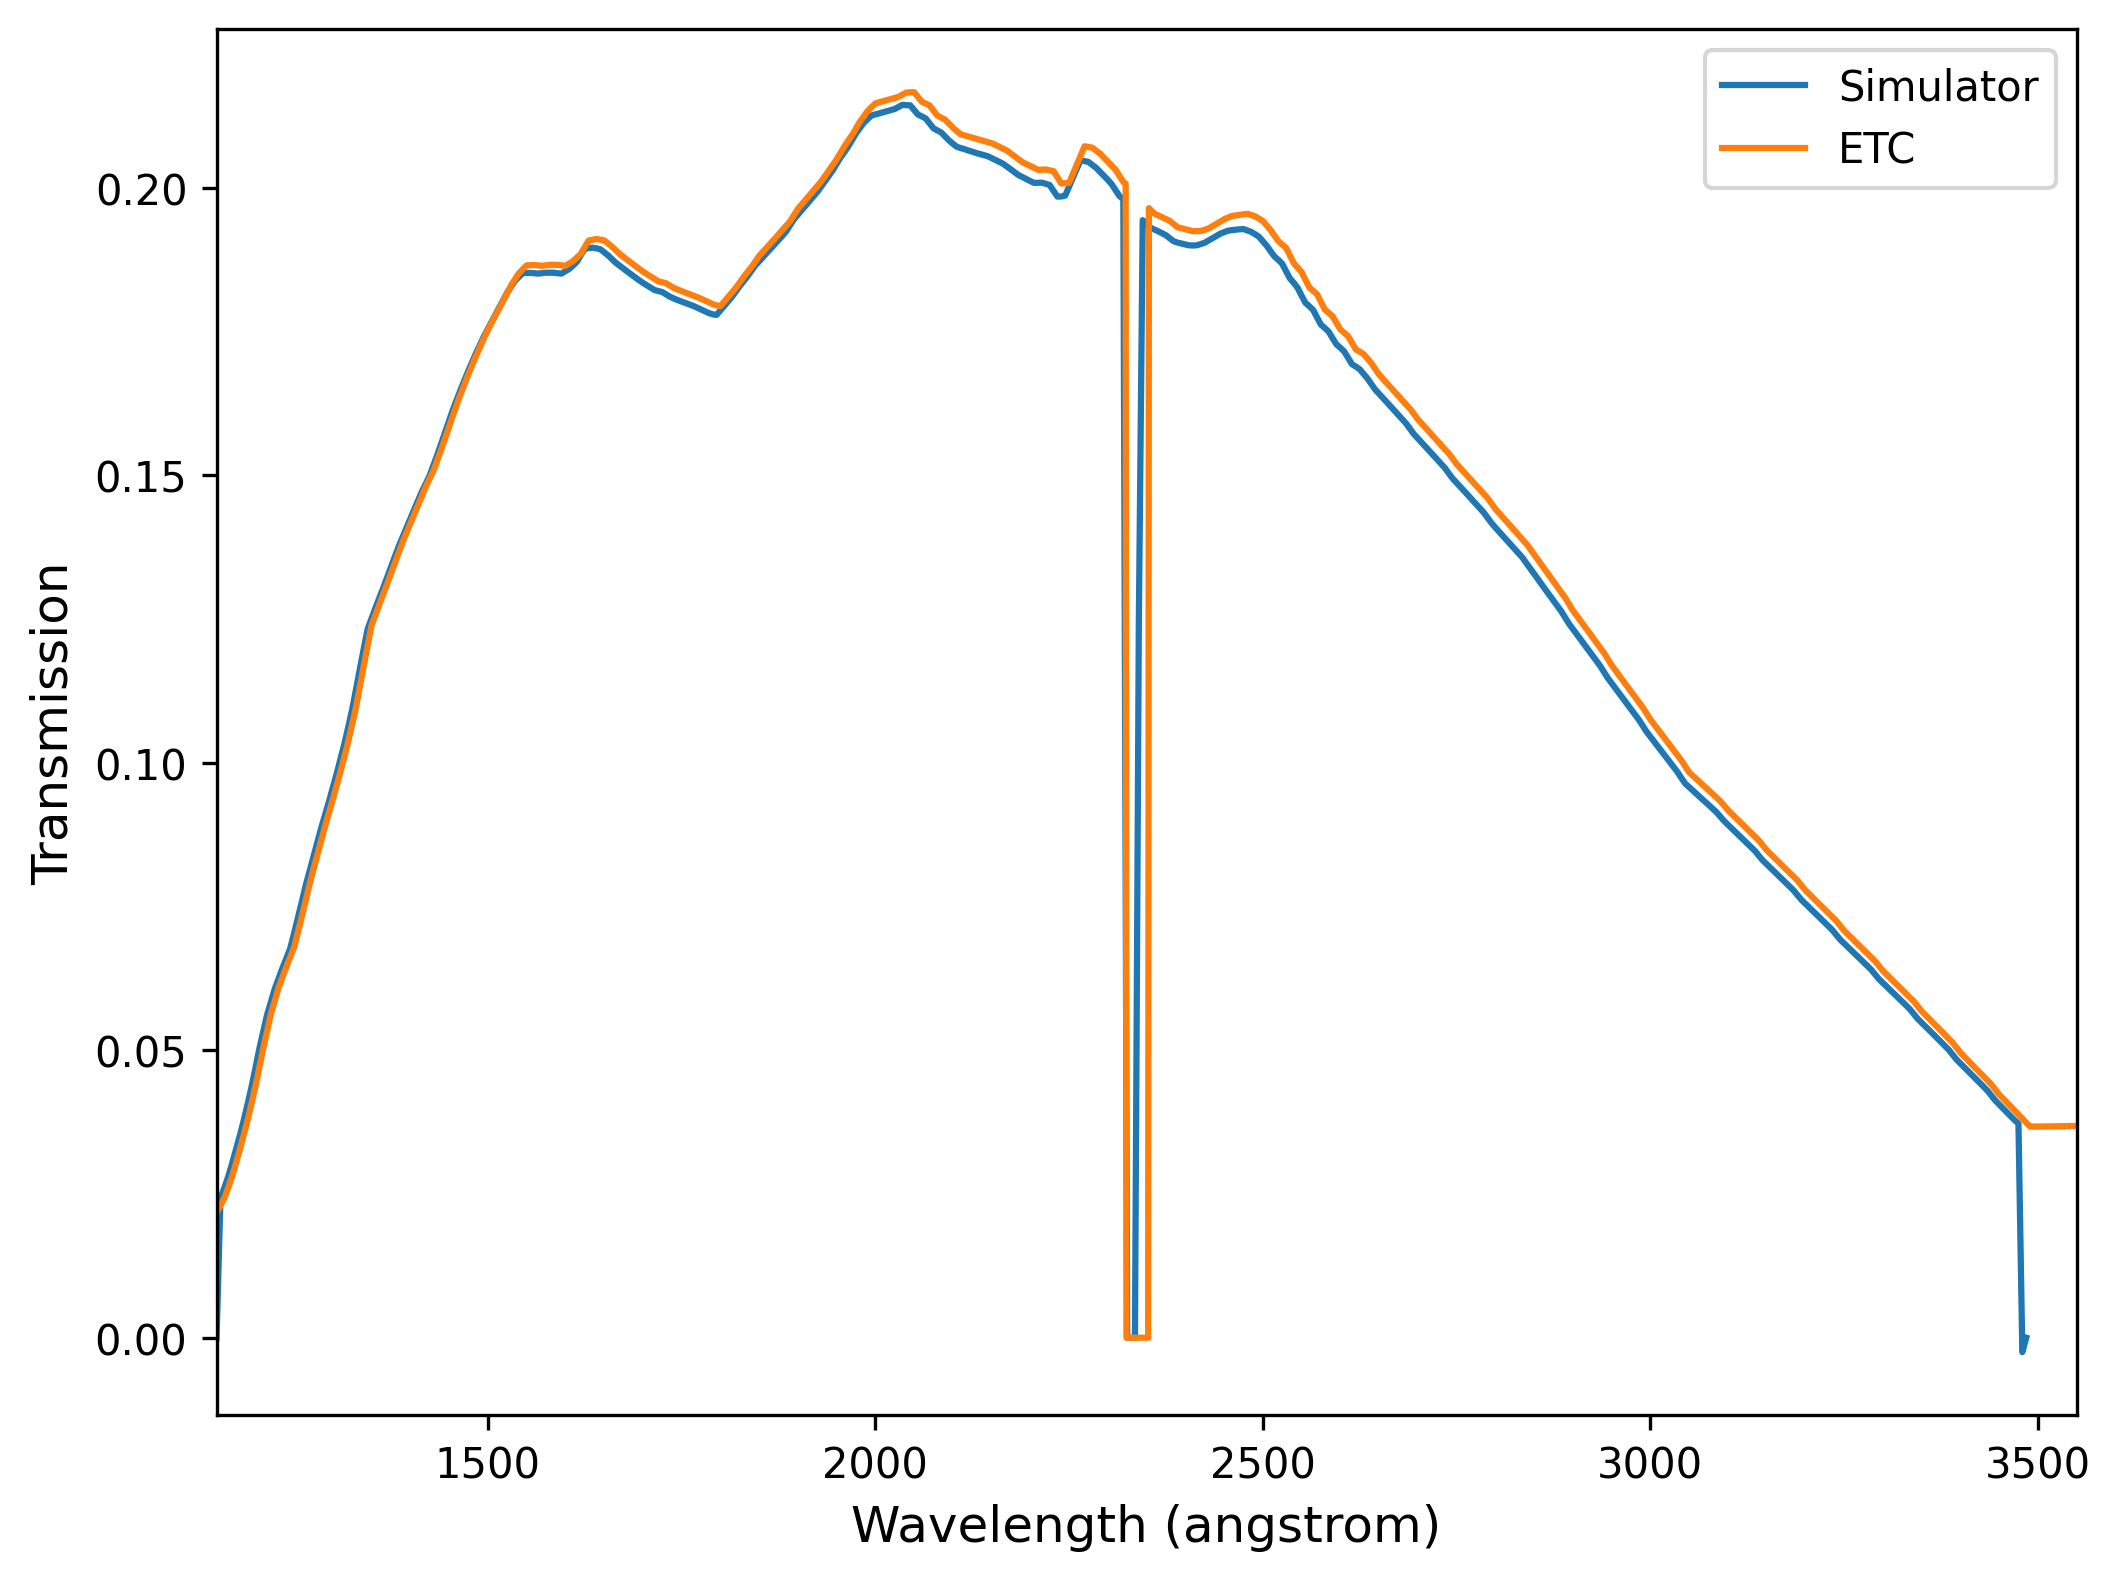

In [9]:
w = WCS(rectified[1].header)
n_lam = rectified[1].data.shape[1]
n_xi = rectified[1].data.shape[0]
pix_x = np.arange(n_lam) 
pix_y = np.zeros(n_lam) 
lam_world = w.all_pix2world(np.column_stack([pix_x, pix_y]), 0)
lam = lam_world[:, 0] * (u.m).to(u.AA)

pix_y = np.arange(n_xi)
pix_x = np.zeros(n_xi) 
world = w.all_pix2world(np.column_stack([pix_x, pix_y]), 0)
xi = world[:, 1] 

nonzero_xi, nonzero_lam = np.where(rectified[1].data > 0) # minimum throughput 1e-06?
nonzero_xi, nonzero_lam = np.unique(nonzero_xi), np.unique(nonzero_lam)
slit_length = xi[np.argmax(nonzero_xi)] - xi[np.argmin(nonzero_xi)]
lam_min, lam_max = lam[np.argmin(nonzero_lam)]*u.AA.to(u.um), lam[np.argmax(nonzero_lam)]*u.AA.to(u.um)
slit_area = 2 * 3600 * u.arcsec**2
plate_scale = (80.0 * u.arcsec / u.mm).to(u.arcsec/u.m)
pixel_area = (pixel_scale / plate_scale)**2

# Integrate along the slit axis
trace1 = rectified[1].data[sorted(nonzero_xi), :].sum(axis=0) * pixel_scale.value / slit_length
print("Pixel area:", pixel_area, "  Slit area:", slit_area/plate_scale**2)

# Get the total count rate of the defined source
input_countrate = constant_source.photons_in_range(wave_min=0.115, wave_max=0.355, area=slit_area/plate_scale**2)[0] # ph / s
print("Total input count rate:", input_countrate)
exptime = optlss.cmds["!OBS.dit"] * optlss.cmds["!OBS.ndit"] * u.s
trace1 = trace1 / (input_countrate.value * exptime.value)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(lam, np.array(trace1), label="Simulator")
plt.plot(lss_bandpass_etc_wave, lss_bandpass_etc_throughput, label='ETC')
ax.set_xlabel("Wavelength (angstrom)", fontsize=12)
ax.set_ylabel("Transmission", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.xlim(1150, 3550)
plt.show()

In [10]:
# TODO: In the block convolution, maybe exclude pixel fluxes that were a result of padding the tile for convolution?
# This is precisely what is causing those wiggles above, particularly in the red end where the PSF shapes vary.

# Why are there any differences at all when the PSFs are turned off? distortion?

# why is the point source run off by a factor of 2